# K-Means Clustering - Segmentasi Konsumen Bantal

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

## 1. Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import re

def load_data(path):
    """
    Load data_bantal - support dua format:
    1. CSV biasa (header + baris data)
    2. SQL INSERT INTO ... VALUES (...)
    """
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Deteksi apakah isi file adalah SQL INSERT
    if 'INSERT INTO' in content or 'VALUES' in content:
        print("Format terdeteksi: SQL INSERT")
        rows = re.findall(r"\(([^)]+)\)", content)
        data = []
        for row in rows:
            # Skip baris definisi kolom SQL
            if any(k in row.lower() for k in ['nama', 'jenis_kelamin', 'insert']):
                continue
            vals = [v.strip().strip("'") for v in row.split(',')]
            if len(vals) >= 7:
                data.append(vals[:12])  # ambil 12 kolom saja

        cols = ['Nama Product', 'Jenis Kelamin', 'Usia', 'Harga', 'Desain',
                'Kenyamanan', 'Durasi Tidur', 'Random Forest', 'Grad. Boosting',
                'Naive Bayes', 'K-Means', 'Kesimpulan']
        df = pd.DataFrame(data, columns=cols[:len(data[0])] if data else cols)
    else:
        print("Format terdeteksi: CSV")
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        # Hapus header duplikat
        for col in df.columns:
            df = df[df[col].astype(str).str.strip().str.lower() != col.strip().lower()]
        df = df.reset_index(drop=True)

    # Konversi numerik
    for col in ['Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

    # Isi NaN dengan median (tidak buang baris)
    for col in ['Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Encode Jenis Kelamin: L=0, P=1
    df['Jenis Kelamin'] = df['Jenis Kelamin'].astype(str).str.strip().str.upper()
    df['Jenis Kelamin'] = df['Jenis Kelamin'].map({'L': 0, 'P': 1}).fillna(0).astype(int)

    print(f"Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
    return df

df = load_data('../dataset/data_bantal.csv')
print()
print(df[['Jenis Kelamin','Usia','Harga','Desain','Kenyamanan','Durasi Tidur']].head(5).to_string())


Format terdeteksi: SQL INSERT
Data berhasil dimuat: 300 baris, 12 kolom

   Jenis Kelamin  Usia  Harga  Desain  Kenyamanan  Durasi Tidur
0              1    23      4       3           1            10
1              0    26      3       5           3             9
2              1    22      1       3           4             4
3              1    45      5       4           3             7
4              0    56      5       5           3             4


## 2. Scaling

In [ ]:
fitur = ['Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']
x_raw = df[fitur].copy()
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_raw)
print("Shape data scaled:", x_scaled.shape)

Shape data scaled: (300, 6)


## 3. Elbow Method

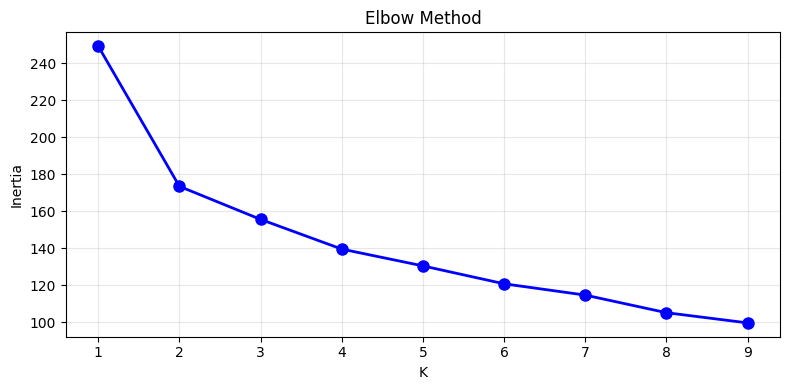

In [ ]:
inertias = []
for k in range(1, 10):
    km_tmp = KMeans(n_clusters=k, random_state=42).fit(x_scaled)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,10), inertias, "bo-", linewidth=2, markersize=8)
plt.xlabel("K"); plt.ylabel("Inertia")
plt.title("Elbow Method"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Training K-Means

In [ ]:
kmean = KMeans(n_clusters=2, random_state=42)
kmean.fit(x_scaled)
df["Cluster"] = kmean.labels_
print("Distribusi cluster:")
print(df["Cluster"].value_counts())

Distribusi cluster:
Cluster
1    156
0    144
Name: count, dtype: int64


## 5. Labeling Otomatis Berdasarkan Analisis

**Perbaikan:** label ditentukan dari rata-rata skor, bukan diasumsikan.

In [ ]:
df["skor_preferensi"] = df["Harga"] + df["Desain"] + df["Kenyamanan"]
rata = df.groupby("Cluster")["skor_preferensi"].mean()
print("Rata-rata skor per cluster:")
print(rata)

cluster_premium = int(rata.idxmax())
cluster_non = 1 - cluster_premium
label_map = {cluster_premium: "Premium", cluster_non: "Non-Premium"}
df["Cluster_Label"] = df["Cluster"].map(label_map)

print(f"\nCluster {cluster_premium} → Premium")
print(f"Cluster {cluster_non} → Non-Premium")
print()
print(df["Cluster_Label"].value_counts())

Rata-rata skor per cluster:
Cluster
0    8.722222
1    8.743590
Name: skor_preferensi, dtype: float64

Cluster 1 → Premium
Cluster 0 → Non-Premium

Cluster_Label
Premium        156
Non-Premium    144
Name: count, dtype: int64


## 6. Visualisasi

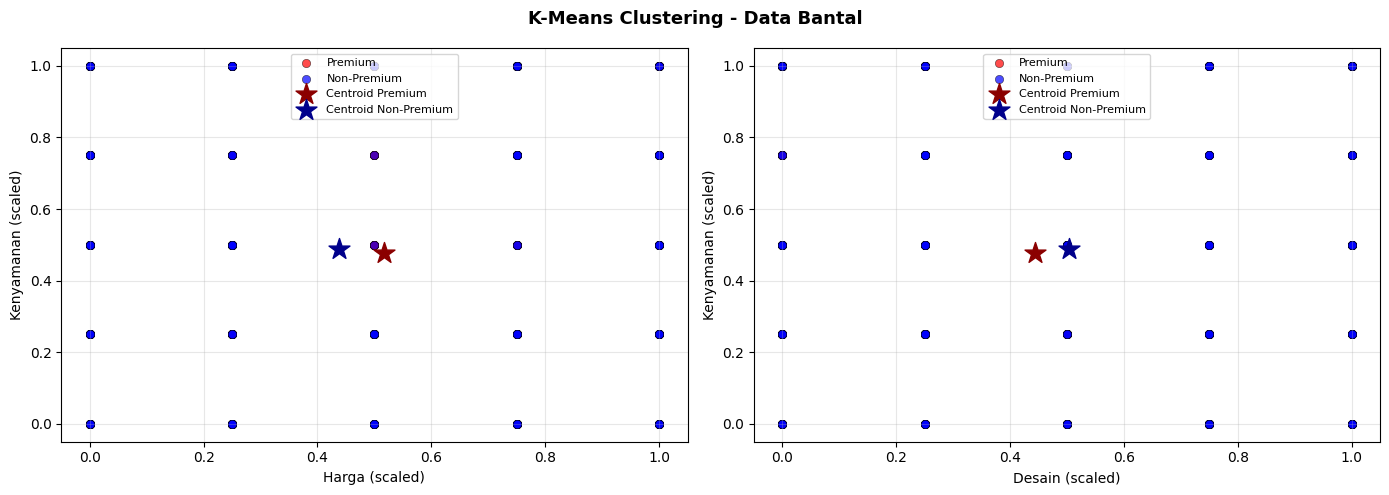

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Premium": "red", "Non-Premium": "blue"}

for ax, (xi, yi, xlabel, ylabel) in zip(axes, [
    (2, 4, "Harga (scaled)", "Kenyamanan (scaled)"),
    (3, 4, "Desain (scaled)", "Kenyamanan (scaled)")
]):
    for lbl, col in colors.items():
        mask = df["Cluster_Label"] == lbl
        ax.scatter(x_scaled[mask, xi], x_scaled[mask, yi],
                   c=col, label=lbl, alpha=0.7, edgecolors="k", linewidths=0.4)
    ax.scatter(*kmean.cluster_centers_[cluster_premium, [xi,yi]],
               color="darkred", marker="*", s=250, zorder=5, label="Centroid Premium")
    ax.scatter(*kmean.cluster_centers_[cluster_non, [xi,yi]],
               color="darkblue", marker="*", s=250, zorder=5, label="Centroid Non-Premium")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("K-Means Clustering - Data Bantal", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Simpan Model

In [ ]:
import pickle
with open("../flask-app/kmeans_model.pkl", "wb") as f:
    pickle.dump({"model": kmean, "scaler": scaler,
                 "cluster_premium": cluster_premium,
                 "cluster_non_premium": cluster_non}, f)
print("✅ kmeans_model.pkl tersimpan")
print(f"   Cluster Premium     = {cluster_premium}")
print(f"   Cluster Non-Premium = {cluster_non}")

✅ kmeans_model.pkl tersimpan
   Cluster Premium     = 1
   Cluster Non-Premium = 0
